In [1]:
import pandas as pd
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import math
from matplotlib.ticker import MultipleLocator
import datetime

In [4]:
#all_books = pd.read_csv('DocumentMetadata.csv', parse_dates=['EntryCreationDate'])
#days_read = pd.read_csv('ReadingInsightsDayUnits.csv', parse_dates=['reading_tracked_on_day'])
#book_session = pd.read_csv('reading-insights-sessions.csv', parse_dates=['end_time', 'start_time'])
session = pd.read_csv('datasets/Kindle.Devices.ReadingSession.csv', parse_dates=['start_timestamp', 'end_timestamp'])
#completed_books = pd.read_csv('TitlesCompleted.csv')

In [11]:
session['total_reading_millis'].sum()

np.float64(371650900.0)

In [10]:
session['number_of_page_flips'].sum()

np.float64(11614.0)

In [5]:
session = session[session['total_reading_millis'].notna()].copy()

In [6]:
session['start_timestamp'] = pd.to_datetime(session['start_timestamp'])
session['end_timestamp'] = pd.to_datetime(session['end_timestamp'])

In [7]:
session['start_local'] = session['start_timestamp'].dt.tz_convert('America/Vancouver')
session['end_local'] = session['end_timestamp'].dt.tz_convert('America/Vancouver')

In [8]:
session['start_date'] = session['start_local'].dt.date
session['end_date'] = session['end_local'].dt.date

In [8]:
read_per_day = session.groupby('start_date')['total_reading_millis'].sum().reset_index()
read_per_day['total_minutes'] = (read_per_day['total_reading_millis']/60000).round(2)
read_per_day['total_hours'] = (read_per_day['total_reading_millis']/3600000).round(2)

In [9]:
read_per_day.sort_values(by='start_date', ascending=False)

,start_date,total_reading_millis,total_minutes,total_hours
54,2026-02-22,163000.0,2.72,0.05
53,2026-02-21,8194200.0,136.57,2.28
52,2026-02-20,4909600.0,81.83,1.36
51,2026-02-19,4351000.0,72.52,1.21
50,2026-02-18,4035700.0,67.26,1.12
49,2026-02-17,1860500.0,31.01,0.52
48,2026-02-16,29665400.0,494.42,8.24
47,2026-02-15,21179000.0,352.98,5.88
46,2026-02-14,10649800.0,177.50,2.96
45,2026-02-13,9976100.0,166.27,2.77


In [10]:
total_reading_sec = (session['total_reading_millis'].sum()/1000).round(2)
total_reading_mins = (session['total_reading_millis'].sum()/60000).round(2)
total_reading_hours = (session['total_reading_millis'].sum()/3600000).round(2)
total_reading_days = (session['total_reading_millis'].sum()/86400000).round(2)

In [11]:
total_reading_sec

np.float64(371650.9)

In [12]:
days = int(total_reading_sec // (24 * 3600))
total_reading_sec %= (24 * 3600)

In [13]:
hours = int(total_reading_sec // 3600)
total_reading_sec %= 3600

In [14]:
minutes = int(total_reading_sec // 60)
seconds = int(total_reading_sec % 60)

In [15]:
print(f"Total Time Spent Reading: {int(days)} days, {int(hours)} hours, {int(minutes)} minutes, and {int(seconds)} seconds.")

Total Time Spent Reading: 4 days, 7 hours, 14 minutes, and 10 seconds.


In [16]:
read_per_day

,start_date,total_reading_millis,total_minutes,total_hours
0,2025-12-27,649500.0,10.82,0.18
1,2025-12-28,8954900.0,149.25,2.49
2,2025-12-29,5102000.0,85.03,1.42
3,2025-12-30,4635400.0,77.26,1.29
4,2025-12-31,4430600.0,73.84,1.23
5,2026-01-01,2943200.0,49.05,0.82
6,2026-01-02,4832300.0,80.54,1.34
7,2026-01-03,2169100.0,36.15,0.60
8,2026-01-04,2766400.0,46.11,0.77
9,2026-01-05,7025600.0,117.09,1.95


C:\Users\Alia.Sabado\AppData\Local\Temp\ipykernel_14660\1512729622.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  g = sns.lineplot(data=read_per_day, y='total_minutes', x='start_date', palette='pastel', marker='o')


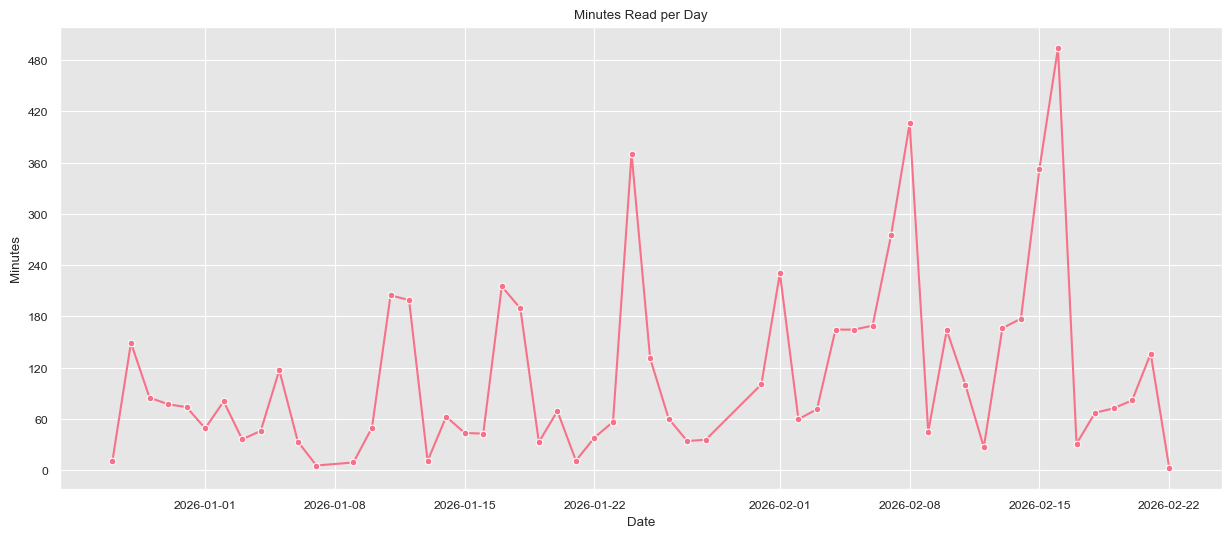

In [17]:
plt.figure(figsize=(15,6))
sns.set_theme()
sns.set_palette(sns.color_palette("husl", 8))
#sns.set_context(rc={'lines.linewidth': 2})
sns.set_context("paper", rc={'lines.linewidth': 1.5})
sns.set_style("darkgrid", {"axes.facecolor": ".9"})
g = sns.lineplot(data=read_per_day, y='total_minutes', x='start_date', palette='pastel', marker='o')
g.set(xlabel='Date', ylabel='Minutes', title='Minutes Read per Day')
g.yaxis.set_major_locator(MultipleLocator(60))
plt.show()

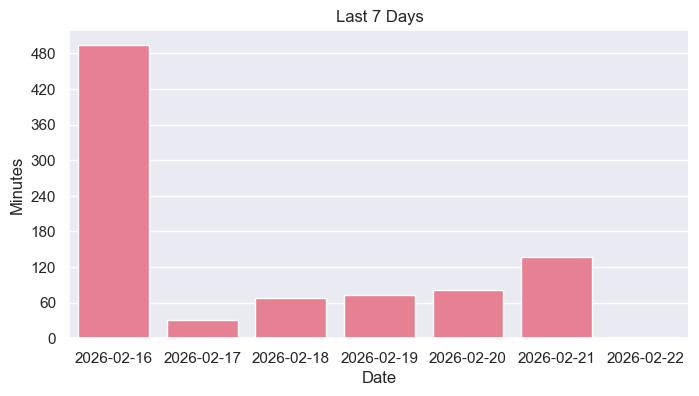

In [18]:
last7days = read_per_day.tail(7)
plt.figure(figsize=(8,4))
sns.set_theme()
sns.set_palette(sns.color_palette("husl", 8))
g = sns.barplot(data=last7days, y='total_minutes', x='start_date')
g.set(xlabel='Date', ylabel='Minutes', title='Last 7 Days')
g.yaxis.set_major_locator(MultipleLocator(60))
plt.show()

In [18]:
session

,start_timestamp,end_timestamp,ASIN,purchased_marketplace,preferred_marketplace,device_family,device_serial_number,device_software_version,content_type,total_reading_millis,number_of_page_flips,start_local,end_local,start_date,end_date
0,2026-01-18 16:15:04+00:00,2026-01-18 16:15:08+00:00,C5E55116FA1A46AFB2C5DFD300E475A8,NaN,www.amazon.ca,Kindle E-reader,GN433X105136074M,4.586210e+09,Personal Document,3500.0,1.0,2026-01-18 08:15:04-08:00,2026-01-18 08:15:08-08:00,2026-01-18,2026-01-18
1,2026-02-09 04:51:56+00:00,2026-02-09 04:52:30+00:00,4ED3C87F5AA7450CAD2C6C8D2354EC41,NaN,www.amazon.ca,Kindle E-reader,GN433X105136074M,4.586210e+09,Personal Document,33900.0,6.0,2026-02-08 20:51:56-08:00,2026-02-08 20:52:30-08:00,2026-02-08,2026-02-08
2,2026-01-25 09:02:25+00:00,2026-01-25 09:06:16+00:00,076B6578B4384616B5880A1E8B7FFD1A,NaN,www.amazon.ca,Kindle E-reader,GN433X105136074M,4.586210e+09,Personal Document,230800.0,6.0,2026-01-25 01:02:25-08:00,2026-01-25 01:06:16-08:00,2026-01-25,2026-01-25
3,2025-12-27 21:37:49+00:00,2025-12-27 21:37:55+00:00,6DB4151DF8904BC1A980E5D385DF1973,NaN,www.amazon.ca,Kindle E-reader,GN433X105136074M,4.586210e+09,Personal Document,5700.0,1.0,2025-12-27 13:37:49-08:00,2025-12-27 13:37:55-08:00,2025-12-27,2025-12-27
4,2026-01-12 08:35:30+00:00,2026-01-12 09:12:42+00:00,3C62C94C637A4554B4472B6174DB48CD,NaN,www.amazon.ca,Kindle E-reader,GN433X105136074M,4.586210e+09,Personal Document,2231800.0,78.0,2026-01-12 00:35:30-08:00,2026-01-12 01:12:42-08:00,2026-01-12,2026-01-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549,2026-02-09 00:32:28+00:00,2026-02-09 01:21:55+00:00,19B3E1A0C08D4F828A835CC0580C675E,NaN,www.amazon.ca,Kindle E-reader,GN433X105136074M,4.586210e+09,Personal Document,2967500.0,44.0,2026-02-08 16:32:28-08:00,2026-02-08 17:21:55-08:00,2026-02-08,2026-02-08
550,2026-02-06 05:20:02+00:00,2026-02-06 06:21:34+00:00,19B3E1A0C08D4F828A835CC0580C675E,NaN,www.amazon.ca,Kindle E-reader,GN433X105136074M,4.586210e+09,Personal Document,3691700.0,71.0,2026-02-05 21:20:02-08:00,2026-02-05 22:21:34-08:00,2026-02-05,2026-02-05
552,2025-12-29 10:57:32+00:00,2025-12-29 10:58:29+00:00,F90795984FFA4037926AA94851BCC0AA,NaN,www.amazon.ca,Kindle E-reader,GN433X105136074M,4.586210e+09,Personal Document,57500.0,6.0,2025-12-29 02:57:32-08:00,2025-12-29 02:58:29-08:00,2025-12-29,2025-12-29
553,2026-01-08 07:54:10+00:00,2026-01-08 07:59:40+00:00,F90795984FFA4037926AA94851BCC0AA,NaN,www.amazon.ca,Kindle E-reader,GN433X105136074M,4.586210e+09,Personal Document,330400.0,16.0,2026-01-07 23:54:10-08:00,2026-01-07 23:59:40-08:00,2026-01-07,2026-01-07
